In [1]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
import pickle
import matplotlib as mpl
import seaborn as sb
%load_ext autoreload
%autoreload 2

In [2]:
import json

path = "info\\non_cnn_analysis.json"
with open(path, 'r') as f:
    results = json.load(f)

path = "info\\cnn_analysis_results.json"
with open(path, 'r') as f:
    cnn_results = json.load(f)

path = "info\\cnn_analysis_results2.json"
with open(path, 'r') as f:
    cnn_results2 = json.load(f)

path = "info\\cnn_analysis_results_orth_rand.json"
with open(path, 'r') as f:
    cnn_results_rand = json.load(f)

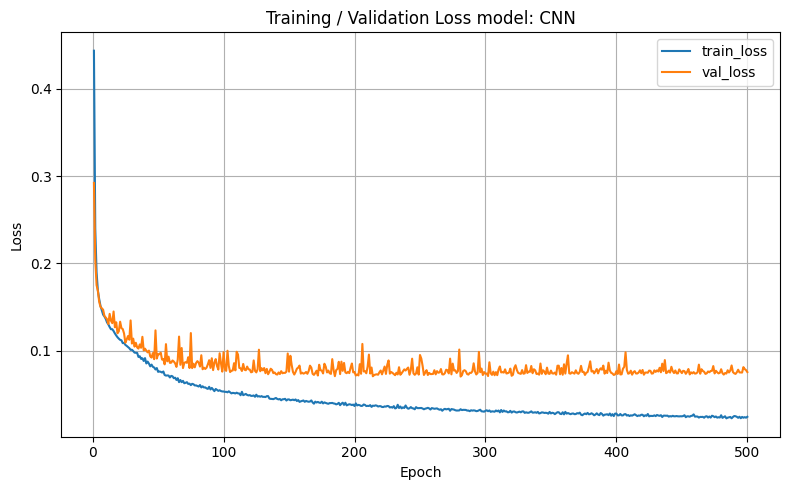

Minimum Validation Loss: 0.07022901310920715
Minimum Training Loss: 0.02235032767057419


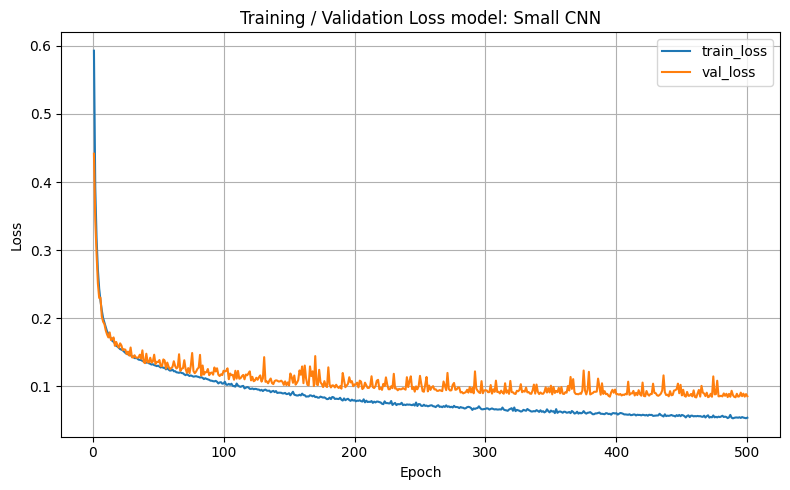

Minimum Validation Loss: 0.08340470829010009
Minimum Training Loss: 0.052705726212263104


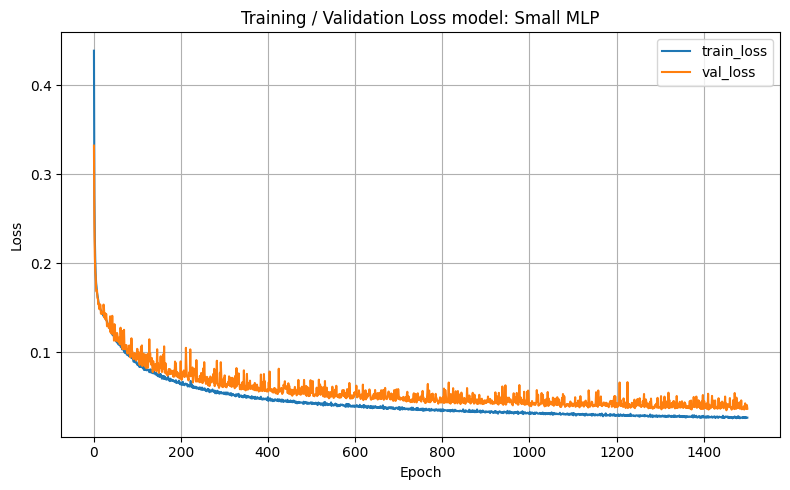

Minimum Validation Loss: 0.035179667961597445
Minimum Training Loss: 0.026115206399559974


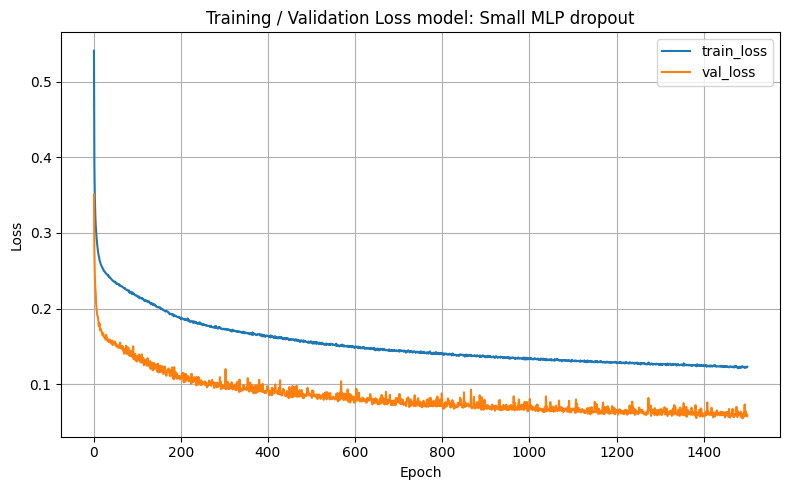

Minimum Validation Loss: 0.054956375068426135
Minimum Training Loss: 0.12122949105501175


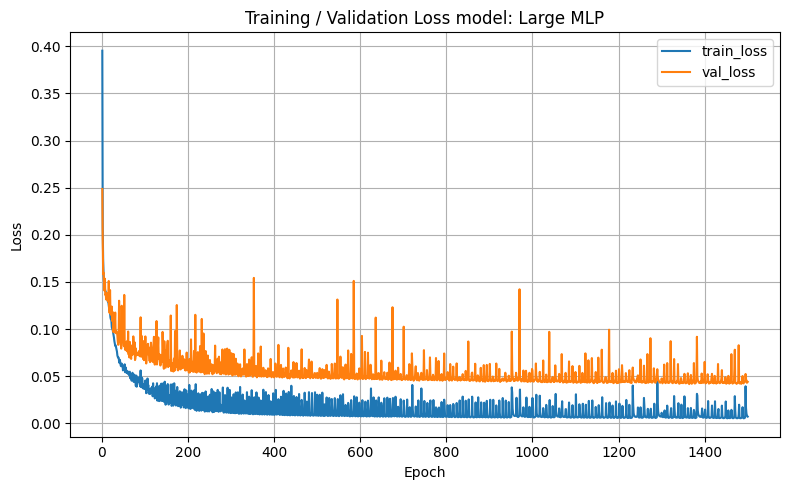

Minimum Validation Loss: 0.04150504760146141
Minimum Training Loss: 0.005181506399810314


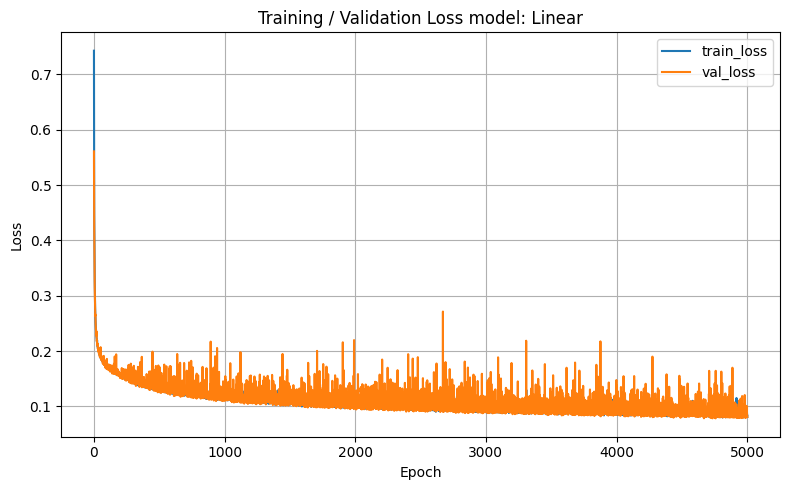

Minimum Validation Loss: 0.07847630426883698
Minimum Training Loss: 0.0799968680858612


In [ ]:
paths_orth = {
    "CNN": r"A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images",
    "Small CNN": r"A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small",
    "Small MLP": r"A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images",
    "Small MLP dropout": r"A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1",

    "Large MLP": r"A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images",
    "Linear": r"A:\Projects\DM + RL\RL\models\final\linear\orth\exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images",
}

paths_LA = {
    "CNN": 
}

PATHS = paths_orth

for name, path in PATHS.items():
    metrics_path = path + "\\metrics.json"

    with open(metrics_path, 'r', encoding='utf-8') as f:
        metrics_data = json.load(f)

    history = metrics_data['history']
    train = history.get('train_loss', [])
    val = history.get('val_loss', [])

    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(train)+1), train, label='train_loss')
    if val:
        plt.plot(range(1, len(val)+1), val, label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.title(f'Training / Validation Loss model: {name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'images/training_validation_loss {metrics_data["args"]["fc1_hidden"]}.png', transparent=True)
    plt.show()

    print(f"Minimum Validation Loss: {min(val) if val else 'N/A'}")
    print(f"Minimum Training Loss: {min(train) if train else 'N/A'}")

### Hyperparameter selection

In [4]:
results.keys()

dict_keys(['mlp\\LA', 'mlp\\orth', 'linear\\LA', 'linear\\orth', 'mlp\\orth rand', 'mlp\\LA rand'])

In [5]:
cnn_LA = cnn_results2['cnn\\LA new']
mlp_LA = results['mlp\\LA']
linear_LA = results['linear\\LA']

In [ ]:
cnn_mlp = cnn_LA['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images']
cnn_mlp_small = cnn_LA['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-small']
cnn_mlp_reg = cnn_LA['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-wd0.0005-do0.1']
cnn_mlp_small_reg = cnn_LA['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-wd0.0005-do0.1 small']

large_mlp

In [8]:
mlp_LA.keys()

dict_keys(['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0-do0.1', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-wd0.0005-mc0', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.2', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-wd0.0005'])